In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [13]:
def load_data(path):
    """
    Load insurance dataset
    """

    df = pd.read_csv(
        path,
        delimiter="|"
    )

    return df


def missing_summary(df):
    """
    Missing value summary
    """

    missing_count = df.isnull().sum()

    missing_percent = (
        missing_count / len(df)
    ) * 100

    summary = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": missing_percent
    })

    return summary.sort_values(
        by="missing_percent",
        ascending=False
    )


def numerical_summary(df):
    """
    Numerical feature summary
    """

    return df.describe().T

In [14]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import zipfile

zip_path = "/content/drive/MyDrive/MachineLearningRating_v3.zip"

extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete")

Extraction complete


In [16]:
import os

os.listdir("/content/data")

['MachineLearningRating_v3.txt']

In [17]:
df = load_data(
    "/content/data/MachineLearningRating_v3.txt"
)

df.head()

/tmp/ipykernel_571/840004128.py:6: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [18]:
df.shape

(1000098, 52)

In [19]:
df.columns.tolist()

['UnderwrittenCoverID',
 'PolicyID',
 'TransactionMonth',
 'IsVATRegistered',
 'Citizenship',
 'LegalType',
 'Title',
 'Language',
 'Bank',
 'AccountType',
 'MaritalStatus',
 'Gender',
 'Country',
 'Province',
 'PostalCode',
 'MainCrestaZone',
 'SubCrestaZone',
 'ItemType',
 'mmcode',
 'VehicleType',
 'RegistrationYear',
 'make',
 'Model',
 'Cylinders',
 'cubiccapacity',
 'kilowatts',
 'bodytype',
 'NumberOfDoors',
 'VehicleIntroDate',
 'CustomValueEstimate',
 'AlarmImmobiliser',
 'TrackingDevice',
 'CapitalOutstanding',
 'NewVehicle',
 'WrittenOff',
 'Rebuilt',
 'Converted',
 'CrossBorder',
 'NumberOfVehiclesInFleet',
 'SumInsured',
 'TermFrequency',
 'CalculatedPremiumPerTerm',
 'ExcessSelected',
 'CoverCategory',
 'CoverType',
 'CoverGroup',
 'Section',
 'Product',
 'StatutoryClass',
 'StatutoryRiskType',
 'TotalPremium',
 'TotalClaims']

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

In [21]:
df.describe()

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05


In [22]:
df["LossRatio"] = (
    df["TotalClaims"] /
    df["TotalPremium"]
)

df["Margin"] = (
    df["TotalPremium"] -
    df["TotalClaims"]
)

df["ClaimFrequency"] = (
    df["TotalClaims"] > 0
).astype(int)

In [23]:
missing_df = missing_summary(df)

missing_df.head(20)

,missing_count,missing_percent
NumberOfVehiclesInFleet,1000098,100.000000
CrossBorder,999400,99.930207
CustomValueEstimate,779642,77.956560
WrittenOff,641901,64.183810
Converted,641901,64.183810
Rebuilt,641901,64.183810
LossRatio,381484,38.144662
NewVehicle,153295,15.327998
Bank,145961,14.594670
AccountType,40232,4.022806


In [24]:
numerical_summary(df)

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,count,mean,std,min,25%,50%,75%,max
UnderwrittenCoverID,1000098.0,1.048175e+05,6.329371e+04,1.000000e+00,5.514300e+04,9.408300e+04,1.391900e+05,3.011750e+05
PolicyID,1000098.0,7.956682e+03,5.290039e+03,1.400000e+01,4.500000e+03,7.071000e+03,1.107700e+04,2.324600e+04
PostalCode,1000098.0,3.020601e+03,2.649854e+03,1.000000e+00,8.270000e+02,2.000000e+03,4.180000e+03,9.870000e+03
mmcode,999546.0,5.487770e+07,1.360381e+07,4.041200e+06,6.005692e+07,6.005842e+07,6.005842e+07,6.506535e+07
RegistrationYear,1000098.0,2.010225e+03,3.261391e+00,1.987000e+03,2.008000e+03,2.011000e+03,2.013000e+03,2.015000e+03
Cylinders,999546.0,4.046642e+00,2.940201e-01,0.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,1.000000e+01
cubiccapacity,999546.0,2.466743e+03,4.428006e+02,0.000000e+00,2.237000e+03,2.694000e+03,2.694000e+03,1.288000e+04
kilowatts,999546.0,9.720792e+01,1.939326e+01,0.000000e+00,7.500000e+01,1.110000e+02,1.110000e+02,3.090000e+02
NumberOfDoors,999546.0,4.019250e+00,4.683144e-01,0.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,6.000000e+00
CustomValueEstimate,220456.0,2.255311e+05,5.645157e+05,2.000000e+04,1.350000e+05,2.200000e+05,2.800000e+05,2.655000e+07


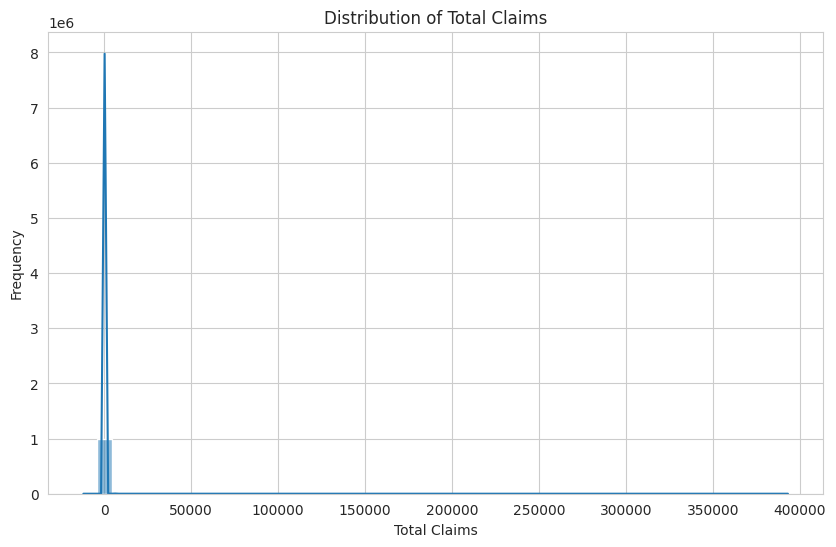

In [25]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["TotalClaims"],
    bins=50,
    kde=True
)

plt.title("Distribution of Total Claims")

plt.xlabel("Total Claims")

plt.ylabel("Frequency")

plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


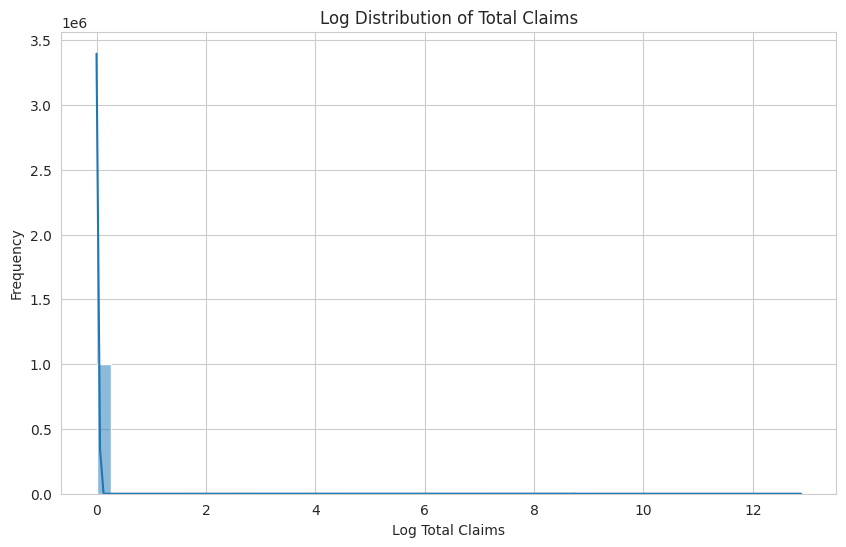

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(
    np.log1p(df["TotalClaims"]),
    bins=50,
    kde=True
)

plt.title("Log Distribution of Total Claims")

plt.xlabel("Log Total Claims")

plt.ylabel("Frequency")

plt.show()

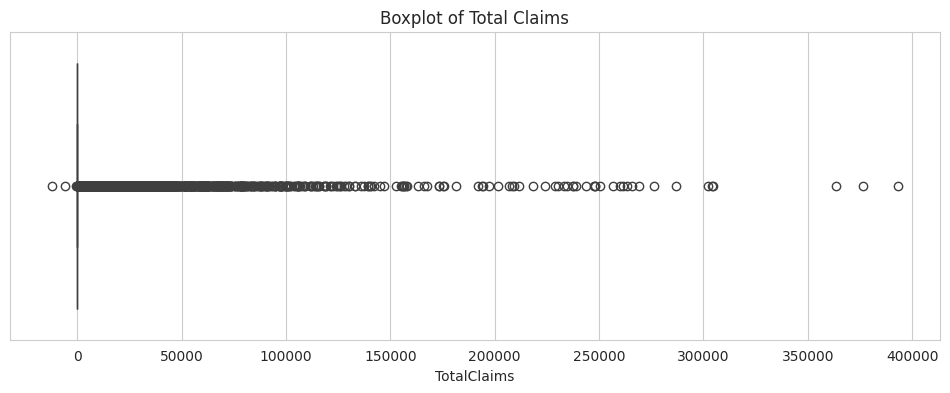

In [27]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    x=df["TotalClaims"]
)

plt.title("Boxplot of Total Claims")

plt.show()

In [28]:
province_analysis = (
    df.groupby("Province")
    .agg({
        "TotalPremium": "sum",
        "TotalClaims": "sum",
        "Margin": "mean",
        "ClaimFrequency": "mean"
    })
)

province_analysis["LossRatio"] = (
    province_analysis["TotalClaims"] /
    province_analysis["TotalPremium"]
)

province_analysis = (
    province_analysis
    .sort_values(
        by="LossRatio",
        ascending=False
    )
)

province_analysis.head()

,TotalPremium,TotalClaims,Margin,ClaimFrequency,LossRatio
Province,,,,,
Gauteng,2.405377e+07,2.939415e+07,-13.558894,0.003356,1.222018
KwaZulu-Natal,1.320908e+07,1.430138e+07,-6.433598,0.002845,1.082693
Western Cape,9.806559e+06,1.038977e+07,-3.414689,0.002166,1.059472
North West,7.490508e+06,5.920250e+06,10.958832,0.002436,0.790367
Mpumalanga,2.836292e+06,2.044675e+06,15.016059,0.002428,0.720897


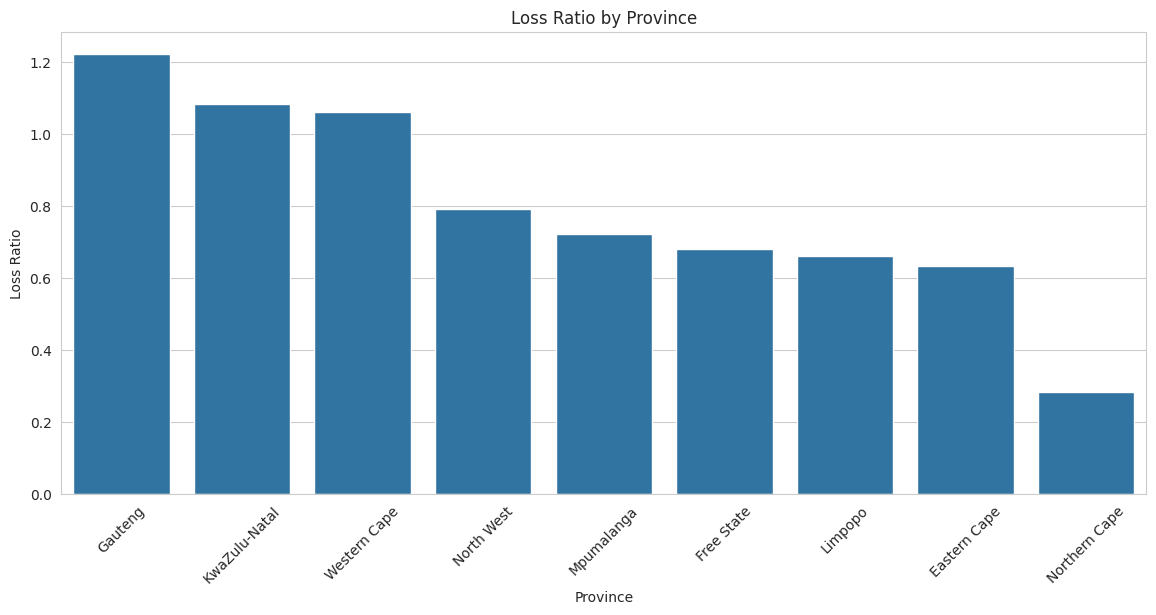

In [29]:
plt.figure(figsize=(14, 6))

sns.barplot(
    x=province_analysis.index,
    y=province_analysis["LossRatio"]
)

plt.xticks(rotation=45)

plt.title("Loss Ratio by Province")

plt.ylabel("Loss Ratio")

plt.xlabel("Province")

plt.show()

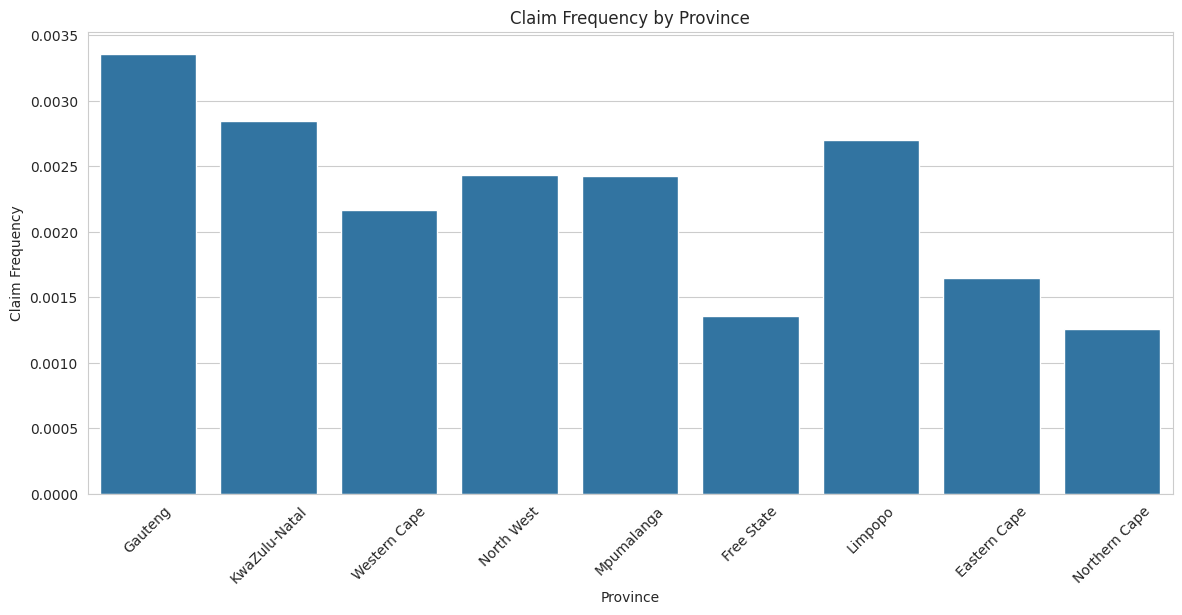

In [30]:
plt.figure(figsize=(14, 6))

sns.barplot(
    x=province_analysis.index,
    y=province_analysis["ClaimFrequency"]
)

plt.xticks(rotation=45)

plt.title("Claim Frequency by Province")

plt.ylabel("Claim Frequency")

plt.xlabel("Province")

plt.show()

In [31]:
gender_analysis = (
    df.groupby("Gender")
    .agg({
        "TotalPremium": "sum",
        "TotalClaims": "sum",
        "Margin": "mean",
        "ClaimFrequency": "mean"
    })
)

gender_analysis["LossRatio"] = (
    gender_analysis["TotalClaims"] /
    gender_analysis["TotalPremium"]
)

gender_analysis

,TotalPremium,TotalClaims,Margin,ClaimFrequency,LossRatio
Gender,,,,,
Female,3.044806e+05,2.502461e+05,8.028787,0.002073,0.821879
Male,1.580143e+06,1.396704e+06,4.284253,0.002195,0.883910
Not specified,5.920275e+07,6.271410e+07,-3.731550,0.002833,1.059311


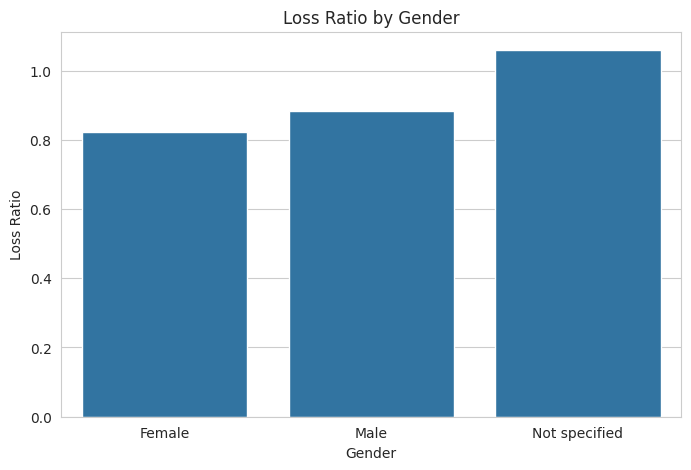

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=gender_analysis.index,
    y=gender_analysis["LossRatio"]
)

plt.title("Loss Ratio by Gender")

plt.ylabel("Loss Ratio")

plt.show()

In [33]:
vehicle_analysis = (
    df.groupby("VehicleType")
    .agg({
        "TotalPremium": "sum",
        "TotalClaims": "sum",
        "ClaimFrequency": "mean"
    })
)

vehicle_analysis["LossRatio"] = (
    vehicle_analysis["TotalClaims"] /
    vehicle_analysis["TotalPremium"]
)

vehicle_analysis = (
    vehicle_analysis
    .sort_values(
        by="LossRatio",
        ascending=False
    )
)

vehicle_analysis.head(10)

,TotalPremium,TotalClaims,ClaimFrequency,LossRatio
VehicleType,,,,
Heavy Commercial,4.609479e+05,7.504746e+05,0.002837,1.628112
Medium Commercial,3.922746e+06,4.119867e+06,0.002927,1.050251
Passenger Vehicle,5.664202e+07,5.937207e+07,0.002771,1.048198
Light Commercial,2.604975e+05,6.045250e+04,0.002053,0.232066
Bus,5.824474e+04,7.996535e+03,0.001504,0.137292


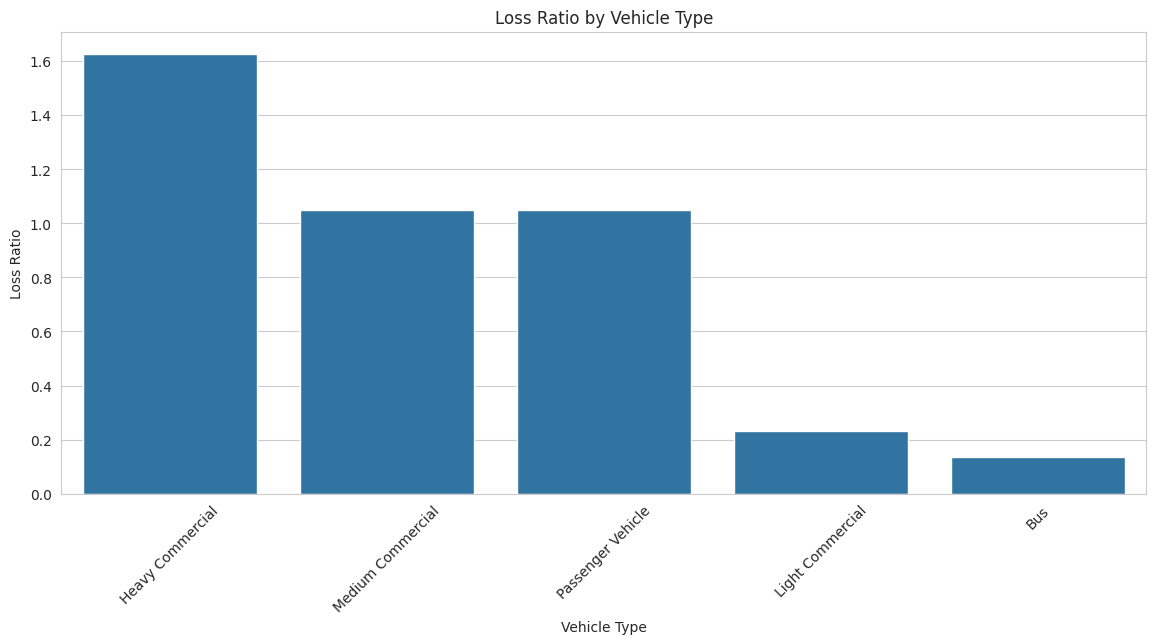

In [34]:
plt.figure(figsize=(14, 6))

sns.barplot(
    x=vehicle_analysis.index,
    y=vehicle_analysis["LossRatio"]
)

plt.xticks(rotation=45)

plt.title("Loss Ratio by Vehicle Type")

plt.ylabel("Loss Ratio")

plt.xlabel("Vehicle Type")

plt.show()

In [35]:
make_analysis = (
    df.groupby("make")
    .agg({
        "TotalClaims": "mean",
        "TotalPremium": "mean"
    })
)

make_analysis["LossRatio"] = (
    make_analysis["TotalClaims"] /
    make_analysis["TotalPremium"]
)

make_analysis = (
    make_analysis
    .sort_values(
        by="LossRatio",
        ascending=False
    )
)

make_analysis.head(10)

,TotalClaims,TotalPremium,LossRatio
make,,,
SUZUKI,419.634546,66.207273,6.338194
JMC,191.684795,46.964886,4.081449
HYUNDAI,174.215195,43.664703,3.989840
POLARSUN,134.044800,43.928696,3.051418
MARCOPOLO,156.794806,52.267675,2.999843
AUDI,137.843083,50.799827,2.713456
BMW,90.558050,45.658312,1.983386
B.A.W,132.934016,76.872229,1.729285
IVECO,89.667017,62.411179,1.436714


## Vehicle Risk Insight

Certain vehicle makes demonstrate substantially higher loss ratios, indicating elevated insurance risk.

Possible explanations include:
- expensive repairs
- higher theft frequency
- driver demographics
- accident susceptibility

Vehicle make appears to be an important predictive feature for pricing models.

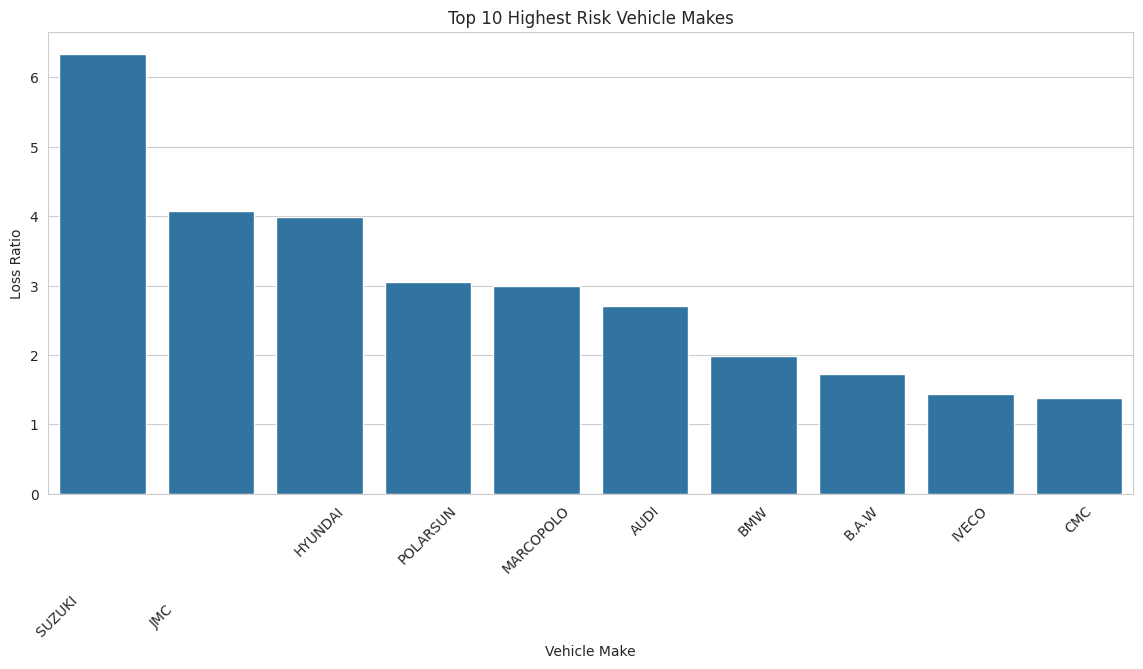

In [36]:
top_makes = make_analysis.head(10)

plt.figure(figsize=(14, 6))

sns.barplot(
    x=top_makes.index,
    y=top_makes["LossRatio"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Highest Risk Vehicle Makes")

plt.ylabel("Loss Ratio")

plt.xlabel("Vehicle Make")

plt.show()

## Portfolio Profitability Insight

The portfolio loss ratio is greater than 1 (104.8%), meaning the insurer paid out more in claims than it earned in premiums during the observed period.

This suggests:
- overall portfolio unprofitability
- potential underpricing of risk
- need for improved segmentation and pricing strategies

In [37]:
overall_loss_ratio = (
    df["TotalClaims"].sum() /
    df["TotalPremium"].sum()
)

overall_loss_ratio

np.float64(1.0477452570332202)

## Correlation Insights

- Margin decreases sharply as TotalClaims increase, which is expected in insurance portfolios.
- TotalPremium has relatively weak correlation with TotalClaims, suggesting premium pricing may not fully reflect actual underlying risk.

In [38]:
df["TransactionMonth"].head()

,TransactionMonth
0,2015-03-01 00:00:00
1,2015-05-01 00:00:00
2,2015-07-01 00:00:00
3,2015-05-01 00:00:00
4,2015-07-01 00:00:00


In [39]:
df["TransactionMonth"] = pd.to_datetime(
    df["TransactionMonth"]
)

In [40]:
monthly_analysis = (
    df.groupby("TransactionMonth")
    .agg({
        "TotalClaims": "sum",
        "TotalPremium": "sum",
        "ClaimFrequency": "mean"
    })
)

monthly_analysis["LossRatio"] = (
    monthly_analysis["TotalClaims"] /
    monthly_analysis["TotalPremium"]
)

monthly_analysis.head()

,TotalClaims,TotalPremium,ClaimFrequency,LossRatio
TransactionMonth,,,,
2013-10-01,0.000000,371.063512,0.000000,0.000000
2013-11-01,50585.078947,21307.467009,0.001672,2.374054
2013-12-01,9283.385965,42484.748888,0.002007,0.218511
2014-01-01,12436.859649,54085.196865,0.001095,0.229949
2014-02-01,62989.307018,60788.436470,0.002910,1.036205


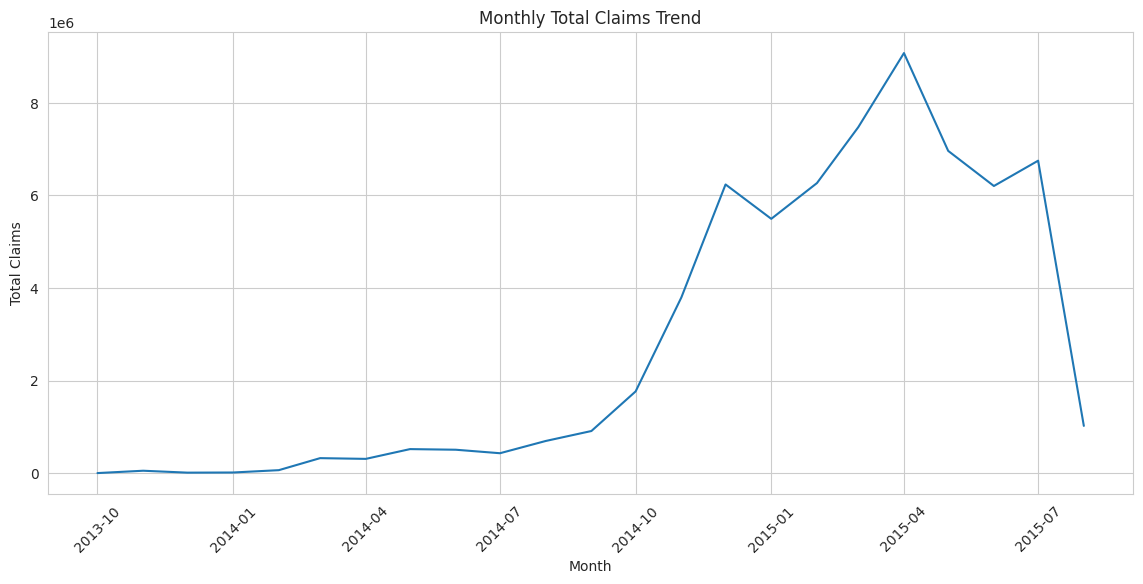

In [41]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis.index,
    monthly_analysis["TotalClaims"]
)

plt.title("Monthly Total Claims Trend")

plt.xlabel("Month")

plt.ylabel("Total Claims")

plt.xticks(rotation=45)

plt.show()

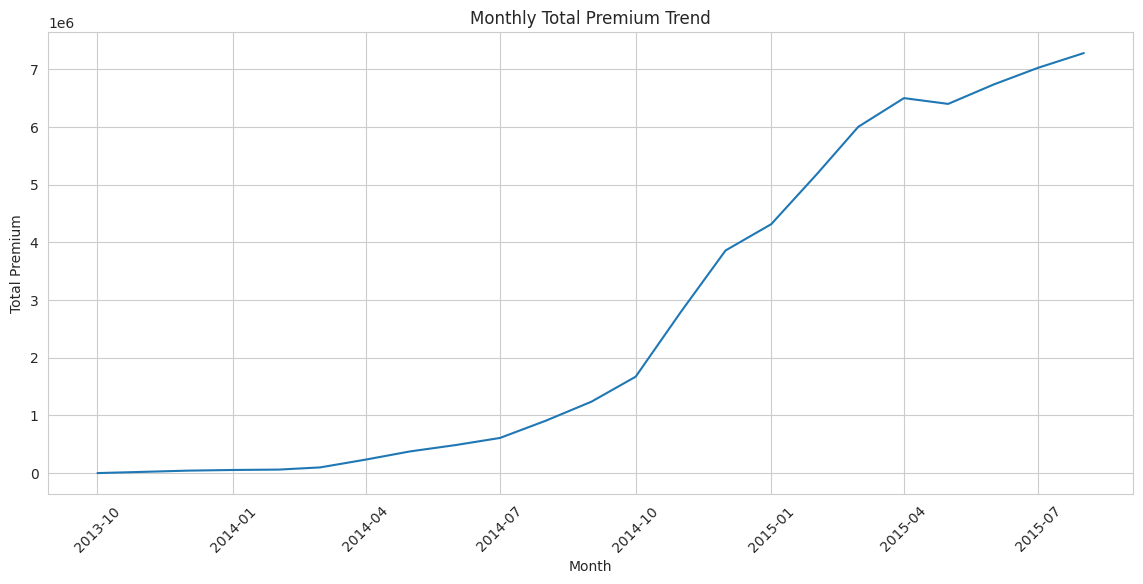

In [42]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis.index,
    monthly_analysis["TotalPremium"]
)

plt.title("Monthly Total Premium Trend")

plt.xlabel("Month")

plt.ylabel("Total Premium")

plt.xticks(rotation=45)

plt.show()

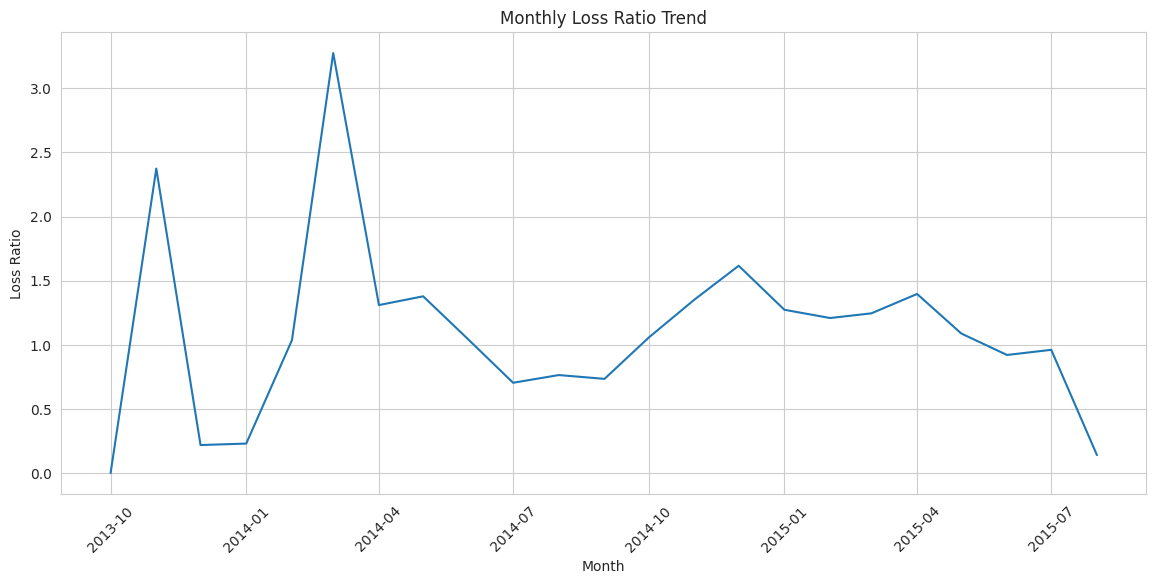

In [43]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis.index,
    monthly_analysis["LossRatio"]
)

plt.title("Monthly Loss Ratio Trend")

plt.xlabel("Month")

plt.ylabel("Loss Ratio")

plt.xticks(rotation=45)

plt.show()

In [44]:
numerical_cols = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate",
    "SumInsured",
    "Margin",
    "LossRatio"
]

corr_matrix = (
    df[numerical_cols]
    .corr()
)

corr_matrix

,TotalPremium,TotalClaims,CustomValueEstimate,SumInsured,Margin,LossRatio
TotalPremium,1.000000,0.121588,0.019965,-0.041174,-0.025174,0.024582
TotalClaims,0.121588,1.000000,0.000853,-0.005129,-0.995327,0.561102
CustomValueEstimate,0.019965,0.000853,1.000000,-0.000213,0.000461,-0.000713
SumInsured,-0.041174,-0.005129,-0.000213,1.000000,0.001160,-0.012327
Margin,-0.025174,-0.995327,0.000461,0.001160,1.000000,-0.562757
LossRatio,0.024582,0.561102,-0.000713,-0.012327,-0.562757,1.000000


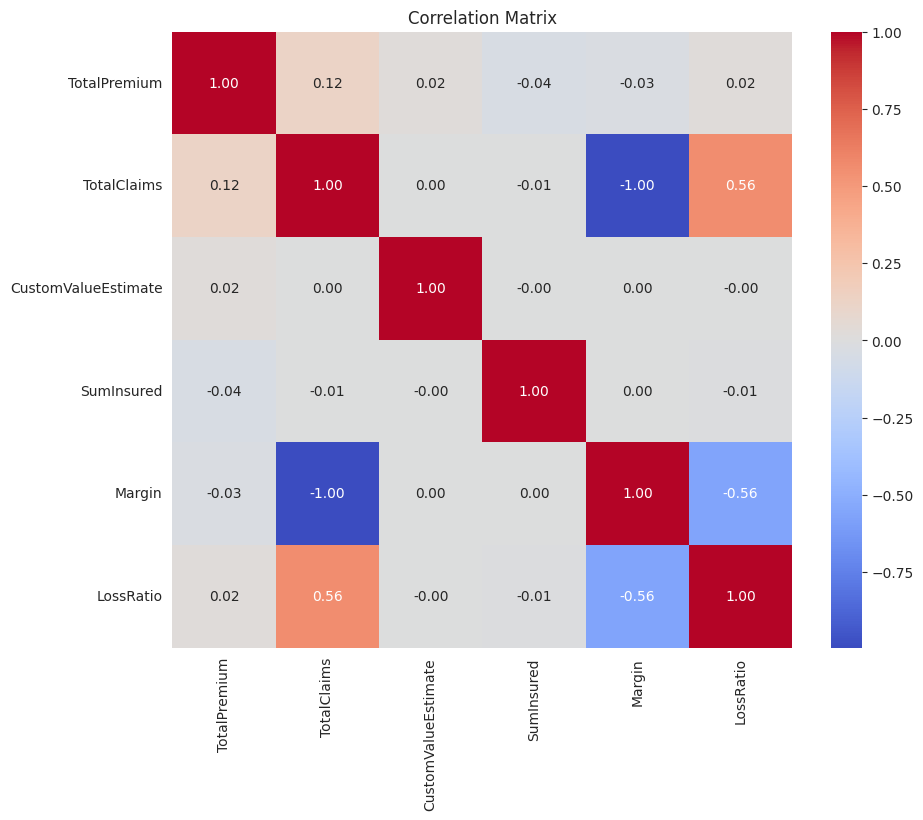

In [45]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

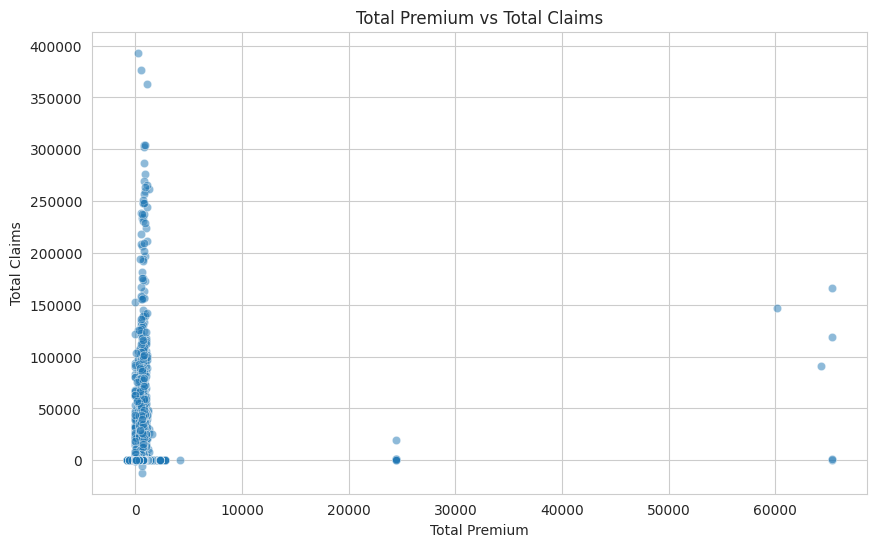

In [46]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df["TotalPremium"],
    y=df["TotalClaims"],
    alpha=0.5
)

plt.title("Total Premium vs Total Claims")

plt.xlabel("Total Premium")

plt.ylabel("Total Claims")

plt.show()

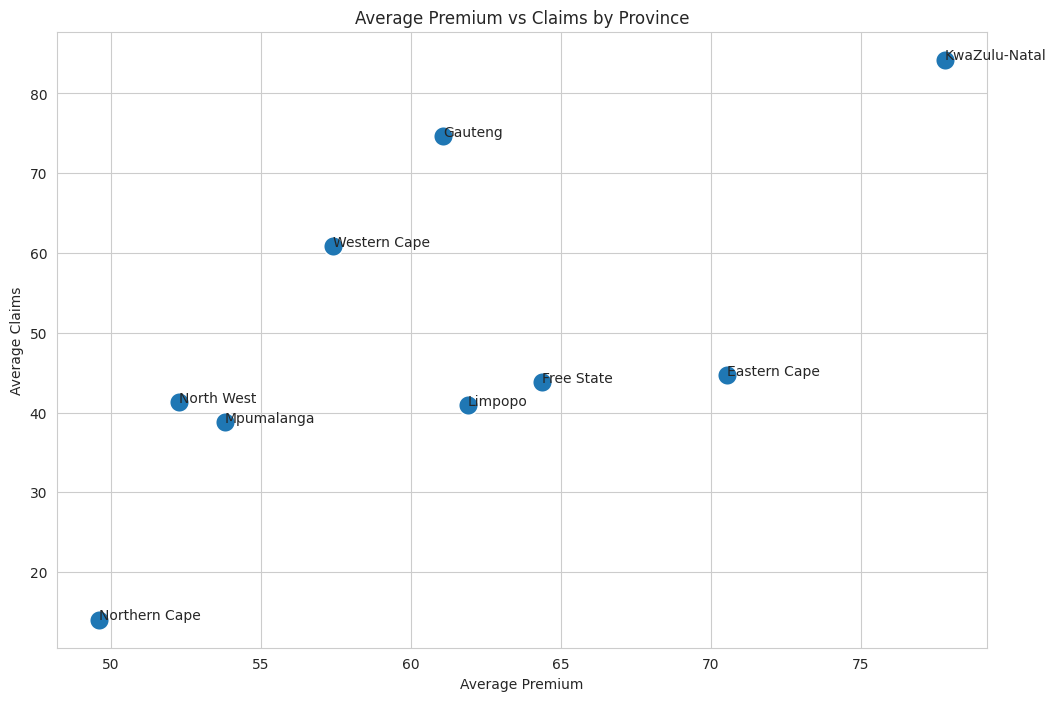

In [47]:
province_scatter = (
    df.groupby("Province")
    .agg({
        "TotalPremium": "mean",
        "TotalClaims": "mean"
    })
)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=province_scatter,
    x="TotalPremium",
    y="TotalClaims",
    s=200
)

for province in province_scatter.index:
    plt.text(
        province_scatter.loc[province, "TotalPremium"],
        province_scatter.loc[province, "TotalClaims"],
        province
    )

plt.title("Average Premium vs Claims by Province")

plt.xlabel("Average Premium")

plt.ylabel("Average Claims")

plt.show()

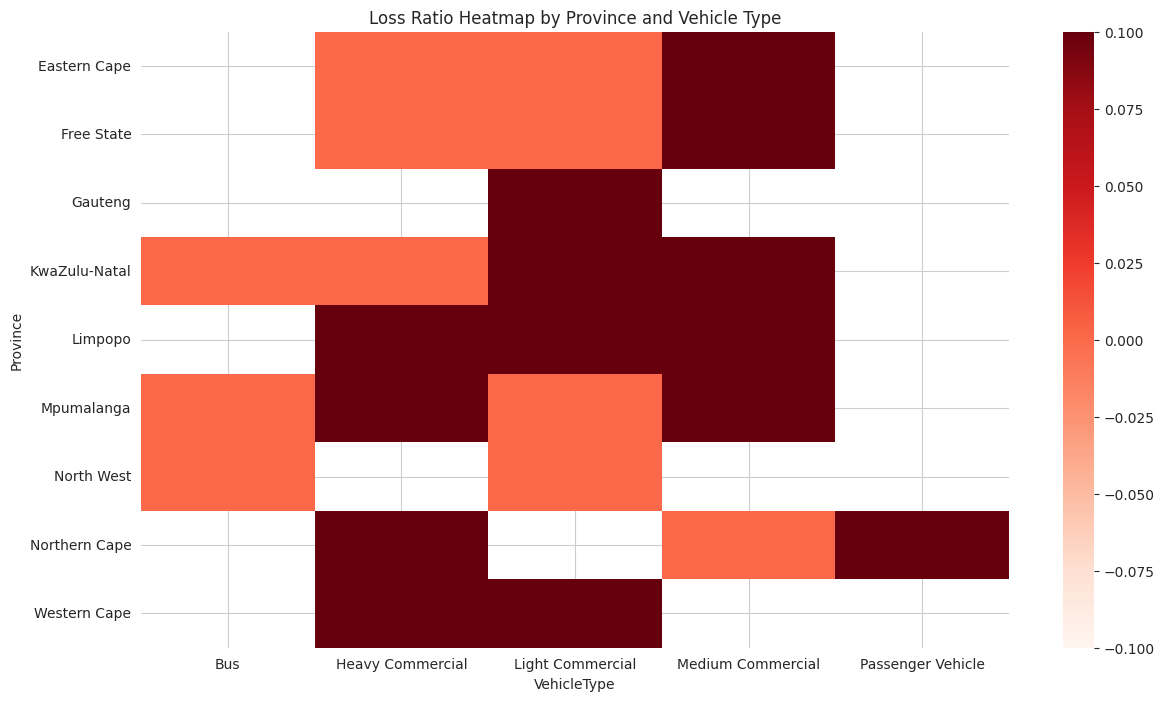

In [48]:
heatmap_data = (
    df.pivot_table(
        values="LossRatio",
        index="Province",
        columns="VehicleType",
        aggfunc="mean"
    )
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="Reds"
)

plt.title("Loss Ratio Heatmap by Province and Vehicle Type")

plt.show()

In [51]:
df.columns.tolist()

['UnderwrittenCoverID',
 'PolicyID',
 'TransactionMonth',
 'IsVATRegistered',
 'Citizenship',
 'LegalType',
 'Title',
 'Language',
 'Bank',
 'AccountType',
 'MaritalStatus',
 'Gender',
 'Country',
 'Province',
 'PostalCode',
 'MainCrestaZone',
 'SubCrestaZone',
 'ItemType',
 'mmcode',
 'VehicleType',
 'RegistrationYear',
 'make',
 'Model',
 'Cylinders',
 'cubiccapacity',
 'kilowatts',
 'bodytype',
 'NumberOfDoors',
 'VehicleIntroDate',
 'CustomValueEstimate',
 'AlarmImmobiliser',
 'TrackingDevice',
 'CapitalOutstanding',
 'NewVehicle',
 'WrittenOff',
 'Rebuilt',
 'Converted',
 'CrossBorder',
 'NumberOfVehiclesInFleet',
 'SumInsured',
 'TermFrequency',
 'CalculatedPremiumPerTerm',
 'ExcessSelected',
 'CoverCategory',
 'CoverType',
 'CoverGroup',
 'Section',
 'Product',
 'StatutoryClass',
 'StatutoryRiskType',
 'TotalPremium',
 'TotalClaims',
 'LossRatio',
 'Margin',
 'ClaimFrequency']

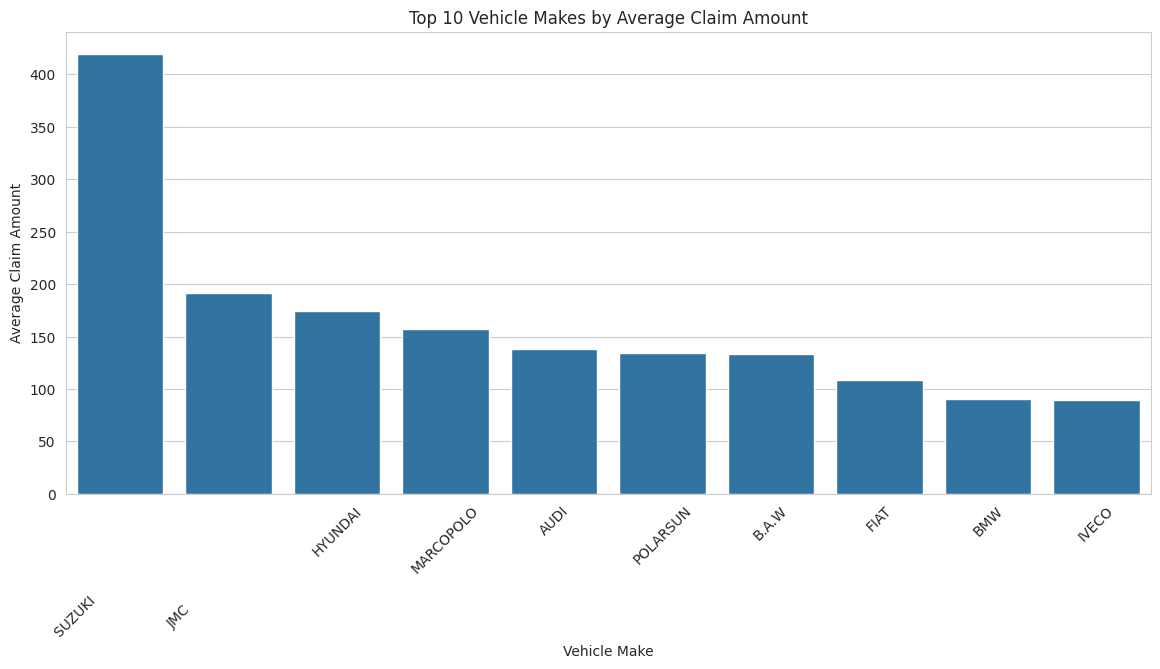

In [53]:
top_claim_makes = (
    df.groupby("make")["TotalClaims"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14, 6))

sns.barplot(
    x=top_claim_makes.index,
    y=top_claim_makes.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Vehicle Makes by Average Claim Amount")

plt.ylabel("Average Claim Amount")

plt.xlabel("Vehicle Make")

plt.show()

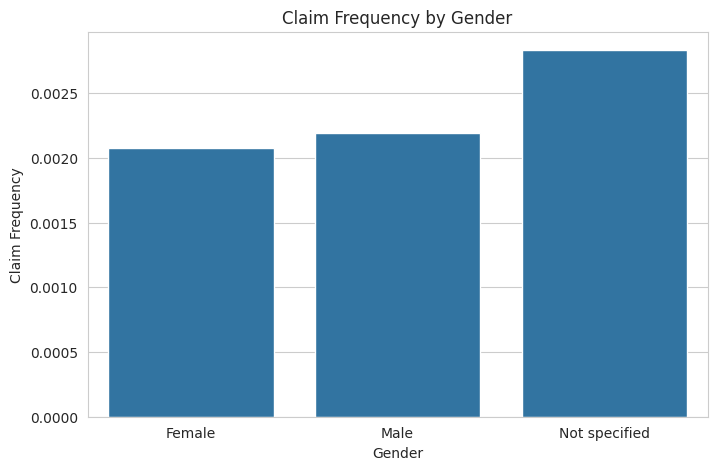

In [50]:
claim_gender = (
    df.groupby("Gender")["ClaimFrequency"]
    .mean()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=claim_gender.index,
    y=claim_gender.values
)

plt.title("Claim Frequency by Gender")

plt.ylabel("Claim Frequency")

plt.xlabel("Gender")

plt.show()

# Final EDA Conclusion

This exploratory analysis identified substantial variation in insurance risk across provinces, genders, vehicle types, and vehicle makes.

Key findings include:
- The portfolio currently operates at a loss ratio above 100%, indicating profitability challenges.
- Geographic location significantly impacts claims behavior.
- Vehicle make and vehicle type strongly influence risk exposure.
- Claims distributions are highly skewed with extreme outliers.
- Risk characteristics vary over time, suggesting dynamic pricing opportunities.

These findings support the need for:
- risk-based segmentation
- improved premium pricing
- predictive modeling for claims probability and severity
- targeted marketing toward lower-risk customer groups